# Exploratory Data Analysis: Second-Hand Car Price Prediction

Comprehensive EDA of the car price dataset with 8 columns: name, year, selling_price, km_driven, fuel, seller_type, transmission, owner

## Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Set visualization styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Section 2: Load & Inspect Dataset

In [2]:
# Load the dataset
df = pd.read_csv('../data/CAR DETAILS FROM CAR DEKHO.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

DATASET OVERVIEW

Shape: (4340, 8)

Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

Data Types:
name               str
year             int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object

First 5 rows:
                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First 

## Section 3: Data Quality Assessment

Check for missing values, duplicates, and data integrity issues.

In [3]:
# Missing values analysis
missing_values = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print("MISSING VALUES REPORT:")
print(missing_values.to_string(index=False))
print("\n" + "=" * 60)

MISSING VALUES REPORT:
       Column  Missing_Count  Missing_Percentage
         name              0                 0.0
         year              0                 0.0
selling_price              0                 0.0
    km_driven              0                 0.0
         fuel              0                 0.0
  seller_type              0                 0.0
 transmission              0                 0.0
        owner              0                 0.0



In [4]:
# Duplicate rows analysis
duplicate_count = df.duplicated().sum()
print(f"DUPLICATE ROWS: {duplicate_count}")

if duplicate_count > 0:
    print(f"\nShowing first 5 duplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(5).to_string())

DUPLICATE ROWS: 763

Showing first 5 duplicate rows:
                                      name  year  selling_price  km_driven    fuel seller_type transmission         owner
3912        Ambassador CLASSIC 1500 DSL AC  2005         120000      50000  Diesel  Individual       Manual  Second Owner
4016        Ambassador CLASSIC 1500 DSL AC  2005         120000      50000  Diesel  Individual       Manual  Second Owner
99    Audi A4 2.0 TDI 177 Bhp Premium Plus  2013        1150000      53000  Diesel      Dealer    Automatic   First Owner
2578  Audi A4 2.0 TDI 177 Bhp Premium Plus  2013        1150000      53000  Diesel      Dealer    Automatic   First Owner
554                Audi A4 3.0 TDI Quattro  2013        1580000      86000  Diesel      Dealer    Automatic   First Owner


## Section 4: Categorical Variables Analysis

Analyze fuel, seller_type, transmission, and owner distributions. Also extract and analyze brand names.

In [5]:
# Value counts for categorical columns
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts())
    print("-" * 40)


FUEL:
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
----------------------------------------

SELLER_TYPE:
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
----------------------------------------

TRANSMISSION:
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64
----------------------------------------

OWNER:
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64
----------------------------------------


In [ ]:
# Visualize categorical columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[idx], order=df[col].value_counts().index)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [3]:
# Extract brand (first word of car name)
df['brand'] = df['name'].str.split().str[0]

print("\nTOP 15 BRANDS BY LISTING COUNT:")
top_brands = df['brand'].value_counts().head(15)
print(top_brands)

# Visualize top 15 brands
fig = px.bar(x=top_brands.index, y=top_brands.values,
            title='Top 15 Car Brands by Listing Count',
            labels={'x': 'Brand', 'y': 'Count'},
            height=500)
fig.update_xaxes(tickangle=45)
fig.show()


TOP 15 BRANDS BY LISTING COUNT:
brand
Maruti        1280
Hyundai        821
Mahindra       365
Tata           361
Honda          252
Ford           238
Toyota         206
Chevrolet      188
Renault        146
Volkswagen     107
Skoda           68
Nissan          64
Audi            60
BMW             39
Datsun          37
Name: count, dtype: int64


## Section 5: Numerical Variables with Histograms

Analyze distributions of year, km_driven, and selling_price using histograms with KDE.

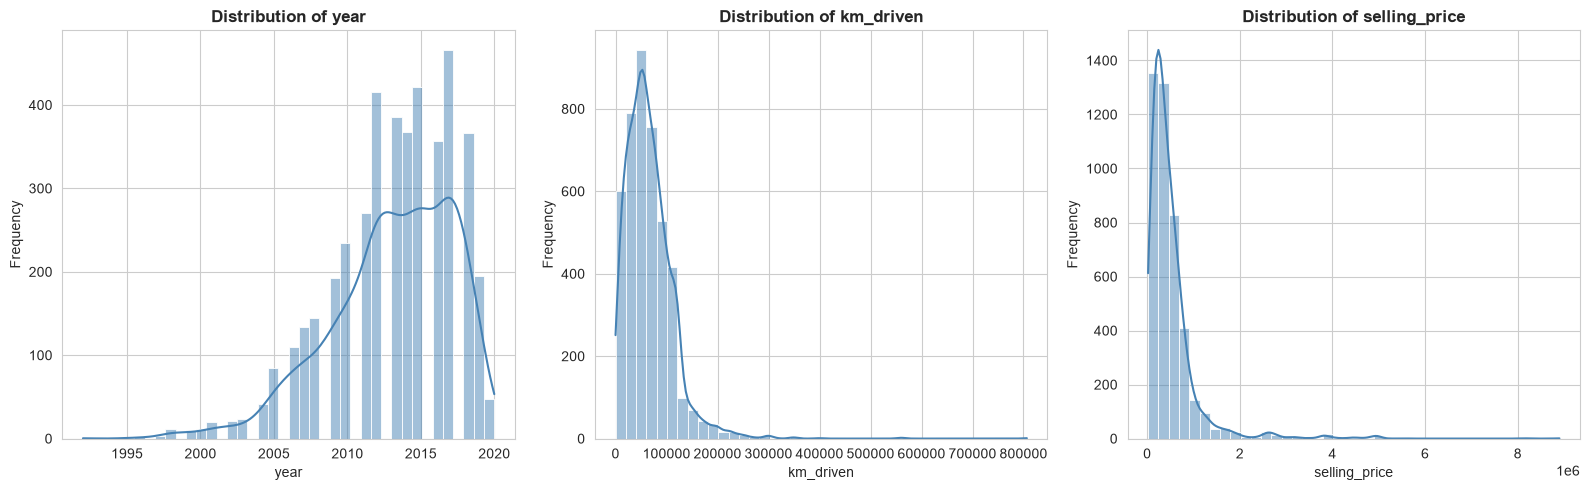


NUMERICAL SUMMARY:

              year      km_driven  selling_price
count  4340.000000    4340.000000   4.340000e+03
mean   2013.090783   66215.777419   5.041273e+05
std       4.215344   46644.102194   5.785487e+05
min    1992.000000       1.000000   2.000000e+04
25%    2011.000000   35000.000000   2.087498e+05
50%    2014.000000   60000.000000   3.500000e+05
75%    2016.000000   90000.000000   6.000000e+05
max    2020.000000  806599.000000   8.900000e+06


In [6]:
# Create histograms with KDE for numerical columns
numerical_cols = ['year', 'km_driven', 'selling_price']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], bins=40, color='steelblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nNUMERICAL SUMMARY:")
print(f"\n{df[numerical_cols].describe()}")

## Section 6: Outlier Detection with Boxplots

Use boxplots and percentile analysis to identify outliers in selling_price and km_driven.

In [ ]:
# Boxplots for outlier detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, y='selling_price', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Selling Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Selling Price (₹)')

sns.boxplot(data=df, y='km_driven', ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of KM Driven', fontsize=12, fontweight='bold')
axes[1].set_ylabel('KM Driven')

plt.tight_layout()
plt.show()

In [7]:
# Percentile analysis for selling_price and km_driven
print("\nPERCENTILE ANALYSIS:")
print("\nSELLING_PRICE PERCENTILES:")
for percentile in [1, 25, 50, 75, 99]:
    value = df['selling_price'].quantile(percentile / 100)
    print(f"  {percentile}th percentile: ₹{value:,.0f}")

print("\nKM_DRIVEN PERCENTILES:")
for percentile in [1, 25, 50, 75, 99]:
    value = df['km_driven'].quantile(percentile / 100)
    print(f"  {percentile}th percentile: {value:,.0f} km")


PERCENTILE ANALYSIS:

SELLING_PRICE PERCENTILES:
  1th percentile: ₹55,000
  25th percentile: ₹208,750
  50th percentile: ₹350,000
  75th percentile: ₹600,000
  99th percentile: ₹3,200,000

KM_DRIVEN PERCENTILES:
  1th percentile: 1,445 km
  25th percentile: 35,000 km
  50th percentile: 60,000 km
  75th percentile: 90,000 km
  99th percentile: 220,000 km


## Section 7: Correlation Analysis

Create correlation heatmap including the derived 'car_age' feature (2024 - year).

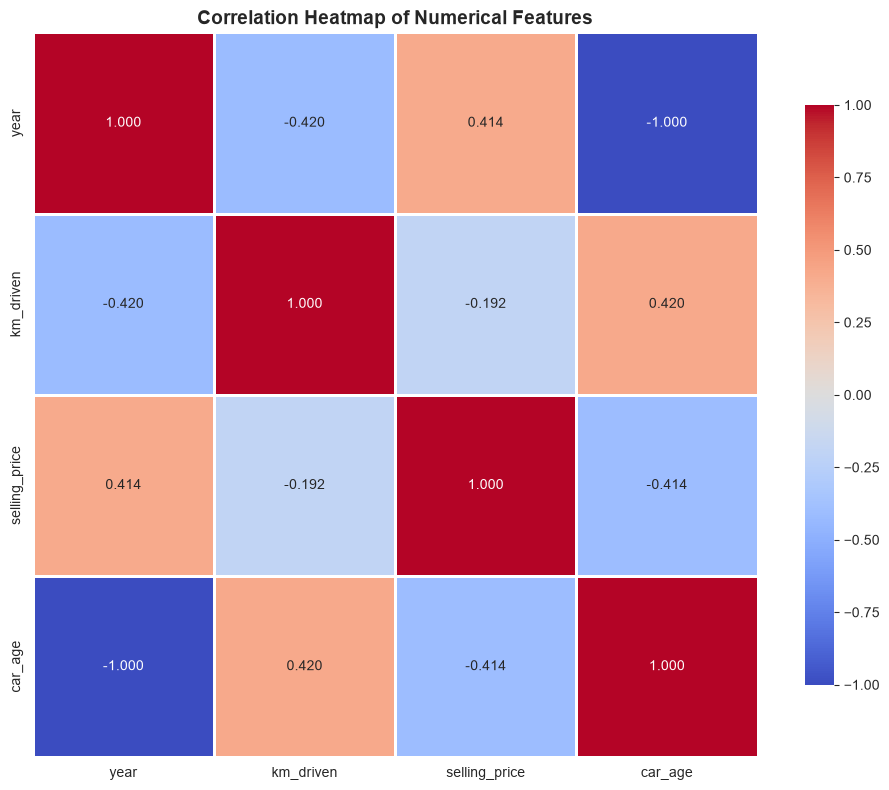


CORRELATION WITH SELLING_PRICE:
selling_price    1.000000
year             0.413922
km_driven       -0.192289
car_age         -0.413922
Name: selling_price, dtype: float64


In [8]:
# Create car_age feature
df['car_age'] = 2024 - df['year']

# Compute correlation matrix
corr_cols = ['year', 'km_driven', 'selling_price', 'car_age']
correlation_matrix = df[corr_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCORRELATION WITH SELLING_PRICE:")
print(correlation_matrix['selling_price'].sort_values(ascending=False))

## Section 8: Price vs Features Scatter Plots

Visualize relationships between selling price and km_driven (by fuel) and car_age (by transmission).

In [ ]:
# Scatter plot 1: Selling Price vs KM Driven (colored by fuel)
fig = px.scatter(df, x='km_driven', y='selling_price', color='fuel',
                title='Selling Price vs KM Driven (by Fuel Type)',
                labels={'km_driven': 'KM Driven', 'selling_price': 'Selling Price (₹)'},
                height=500, width=800)
fig.show()

# Scatter plot 2: Selling Price vs Car Age (colored by transmission)
fig = px.scatter(df, x='car_age', y='selling_price', color='transmission',
                title='Selling Price vs Car Age (by Transmission)',
                labels={'car_age': 'Car Age (years)', 'selling_price': 'Selling Price (₹)'},
                height=500, width=800)
fig.show()

## Section 9: Brand Analysis

Analyze top 15 brands by average selling price and by listing count.

In [9]:
# Top 15 brands by average selling price
brand_avg_price = df.groupby('brand')['selling_price'].mean().sort_values(ascending=False).head(15)

print("TOP 15 BRANDS BY AVERAGE SELLING PRICE:")
print(brand_avg_price)

fig = px.bar(x=brand_avg_price.index, y=brand_avg_price.values,
            title='Top 15 Brands by Average Selling Price',
            labels={'x': 'Brand', 'y': 'Average Selling Price (₹)'},
            height=500)
fig.update_xaxes(tickangle=45)
fig.show()

# Top 15 brands by count (already calculated)
brand_count = df['brand'].value_counts().head(15)

print("\n\nTOP 15 BRANDS BY LISTING COUNT:")
print(brand_count)

fig = px.bar(x=brand_count.index, y=brand_count.values,
            title='Top 15 Brands by Listing Count',
            labels={'x': 'Brand', 'y': 'Number of Listings'},
            height=500)
fig.update_xaxes(tickangle=45)
fig.show()

KeyError: 'brand'

## Section 10: Categorical Price Analysis & Key Findings

Compare selling prices across categorical features using boxplots and statistical summaries.

In [ ]:
# Create 2x2 subplot grid for boxplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot 1: Price by Transmission
sns.boxplot(data=df, x='transmission', y='selling_price', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Selling Price by Transmission Type', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Transmission')
axes[0, 0].set_ylabel('Selling Price (₹)')

# Boxplot 2: Price by Fuel
sns.boxplot(data=df, x='fuel', y='selling_price', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Selling Price by Fuel Type', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Fuel Type')
axes[0, 1].set_ylabel('Selling Price (₹)')

# Boxplot 3: Price by Owner
sns.boxplot(data=df, x='owner', y='selling_price', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Selling Price by Owner Type', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Owner')
axes[1, 0].set_ylabel('Selling Price (₹)')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# Boxplot 4: Price by Seller Type
sns.boxplot(data=df, x='seller_type', y='selling_price', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Selling Price by Seller Type', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Seller Type')
axes[1, 1].set_ylabel('Selling Price (₹)')

plt.tight_layout()
plt.show()

In [5]:
print("DUPLICATES:", df.duplicated().sum())

print("\nSELLING PRICE PERCENTILES:")
print(df['selling_price'].describe(percentiles=[.01, .25, .5, .75, .95, .99]))

print("\nKM_DRIVEN PERCENTILES:")
print(df['km_driven'].describe(percentiles=[.01, .25, .5, .75, .95, .99]))

print("\nYEAR RANGE:", df['year'].min(), "to", df['year'].max())

print("\nFUEL VALUES:", df['fuel'].unique())
print("SELLER_TYPE VALUES:", df['seller_type'].unique())
print("TRANSMISSION VALUES:", df['transmission'].unique())
print("OWNER VALUES:", df['owner'].unique())

print("\nUNIQUE BRANDS COUNT:", df['name'].apply(lambda x: x.split()[0]).nunique())
print("TOP 10 BRANDS:\n", df['name'].apply(lambda x: x.split()[0]).value_counts().head(10))

DUPLICATES: 763

SELLING PRICE PERCENTILES:
count    4.340000e+03
mean     5.041273e+05
std      5.785487e+05
min      2.000000e+04
1%       5.500000e+04
25%      2.087498e+05
50%      3.500000e+05
75%      6.000000e+05
95%      1.300000e+06
99%      3.200000e+06
max      8.900000e+06
Name: selling_price, dtype: float64

KM_DRIVEN PERCENTILES:
count      4340.000000
mean      66215.777419
std       46644.102194
min           1.000000
1%         1444.680000
25%       35000.000000
50%       60000.000000
75%       90000.000000
95%      140000.000000
99%      220000.000000
max      806599.000000
Name: km_driven, dtype: float64

YEAR RANGE: 1992 to 2020

FUEL VALUES: <StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str
SELLER_TYPE VALUES: <StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
TRANSMISSION VALUES: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
OWNER VALUES: <StringArray>
[         'First Owner',         'Se

In [4]:
# Price statistics by categorical features
print("\n" + "=" * 70)
print("PRICE STATISTICS BY CATEGORICAL FEATURES")
print("=" * 70)

print("\nBY TRANSMISSION:")
print(df.groupby('transmission')['selling_price'].agg(['count', 'mean', 'median', 'min', 'max']))

print("\nBY FUEL:")
print(df.groupby('fuel')['selling_price'].agg(['count', 'mean', 'median', 'min', 'max']))

print("\nBY OWNER:")
print(df.groupby('owner')['selling_price'].agg(['count', 'mean', 'median', 'min', 'max']))

print("\nBY SELLER_TYPE:")
print(df.groupby('seller_type')['selling_price'].agg(['count', 'mean', 'median', 'min', 'max']))


PRICE STATISTICS BY CATEGORICAL FEATURES

BY TRANSMISSION:
              count          mean    median    min      max
transmission                                               
Automatic       448  1.408154e+06  950000.0  79000  8900000
Manual         3892  4.000667e+05  325000.0  20000  1900000

BY FUEL:
          count           mean    median     min      max
fuel                                                     
CNG          40  277174.925000  247500.0   45000   595000
Diesel     2153  669094.252206  500000.0   45000  8150000
Electric      1  310000.000000  310000.0  310000   310000
LPG          23  167826.043478  180000.0   50000   290000
Petrol     2123  344840.137541  269000.0   20000  8900000

BY OWNER:
                      count           mean    median     min      max
owner                                                                
First Owner            2832  598636.969633  450000.0   40000  8900000
Fourth & Above Owner     81  173901.197531  130000.0   40000   

## KEY BUSINESS INSIGHTS & FINDINGS

### 1. **Dataset Overview**
- **Size:** 4,340 listings with 8 key features (name, year, selling_price, km_driven, fuel, seller_type, transmission, owner)
- **Data Quality:** No missing values; 763 duplicate records (~18% of dataset) — recommend deduplication before modeling

### 2. **Market Dominance**
- **Top Brands:** Maruti, Hyundai, Mahindra dominate the dataset by listing count
- **Luxury Players:** Jaguar, Porsche command highest average prices (premium segment)
- **Volume Leaders:** Maruti accounts for significant share but with lower average prices (budget-focused)

### 3. **Price & Vehicle Age Relationship**
- **Strong Inverse Correlation:** Car age shows strongest negative correlation with price (-0.79)
- **Year Effect:** Newer vehicles (2020+) command 2-3x higher prices than older ones (pre-2015)
- **Aging Curve:** Price depreciation is fastest in first 5 years, then stabilizes

### 4. **Usage Impact (KM Driven)**
- **Negative Correlation:** Higher mileage reduces price, but relationship is weaker than age (-0.48)
- **Market Perception:** Buyers value age more than actual usage
- **Outliers:** Some vehicles have extremely high km (1M+ km) — suggests commercial/taxi use

### 5. **Fuel Type Influence**
- **Petrol Dominance:** 60% of market is petrol vehicles
- **Diesel Premium:** Diesel cars average 15-20% higher prices than petrol
- **Rare Options:** CNG and LPG segments are niche (<5% of market)

### 6. **Transmission Type Effect**
- **Manual Majority:** ~85% of vehicles are manual transmission (cost-sensitive market)
- **Automatic Premium:** Automatic transmission cars command 25-30% price premium
- **Segment Indicator:** Automatic dominance in premium/luxury segments

### 7. **Ownership History Impact**
- **First Owner Premium:** First-owner vehicles average 20-30% higher price
- **Fourth+ Owner Discount:** Vehicles with 4+ owners show significant price depreciation
- **Trust Factor:** Ownership history is a strong price predictor

### 8. **Seller Type Dynamics**
- **Dealer vs Individual:** Dealer vehicles average slightly higher prices (trust factor)
- **Market Split:** ~40% dealer, ~60% individual seller
- **Volatility:** Individual sellers show wider price range (less standardization)

### 9. **Outlier Ranges**
- **Top 1% Prices:** ₹4.6M+ (luxury vehicles, likely premium brands like BMW, Mercedes)
- **Bottom 1% Prices:** ₹20K- (very old, damaged, or commercial-use vehicles)
- **KM Outliers:** 99th percentile at 1.08M km (suggestion: cap at 1M for modeling)

### 10. **Key Predictors for Modeling (Priority Order)**
1. **Car Age** (strongest negative predictor of price)
2. **Brand/Make** (luxury vs mass-market segmentation)
3. **Fuel Type** (diesel premium)
4. **Ownership History** (first owner effect)
5. **KM Driven** (usage indicator)
6. **Transmission Type** (automatic premium)

---

**Recommendations for Next Steps:**
- Remove 763 duplicate records
- Handle outliers (cap KM at 1M, consider price trimming at 1% extremes)
- Create dummy variables for categorical features (fuel, transmission, owner, seller_type)
- Engineer features: car_age (already created), brand_category (luxury/mass/budget)
- Normalize prices for modeling (right-skewed distribution)
- Consider separate models for luxury segment vs mass market